# Load Modules

In [3]:
import itertools
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import expon, norm, beta
from scipy.ndimage import gaussian_filter
from scipy.stats import ttest_ind
import matplotlib.transforms as mtransforms

# install PyFish via https://bitbucket.org/schwarzlab/pyfish
import pyfish
from pyfish import process_data, fish_plot
from pyfish.core import *

from plotting import *

In [4]:
%load_ext autoreload
%autoreload 2

# Plotting parameters

In [4]:
set_plotting_params()

In [5]:
if not os.path.isdir('figures_first_submission'):
    os.mkdir('figures_first_submission')

# Define plotting functions

# Main Figures

## Load data

In [8]:
confinement_data_df, confinement_data_fish, confinement_lines = load_final_confinement(selection_fish=[41, 19, 35])
metrics_over_time = load_final_metrics_over_time()
example_trajectories_df, example_trajectories_fish, example_trajectories_lines  = load_final_example_trajectories(selection=[11, 33, 14], first_gen=0)
fitness_data = load_final_fitness()

## Fig 3

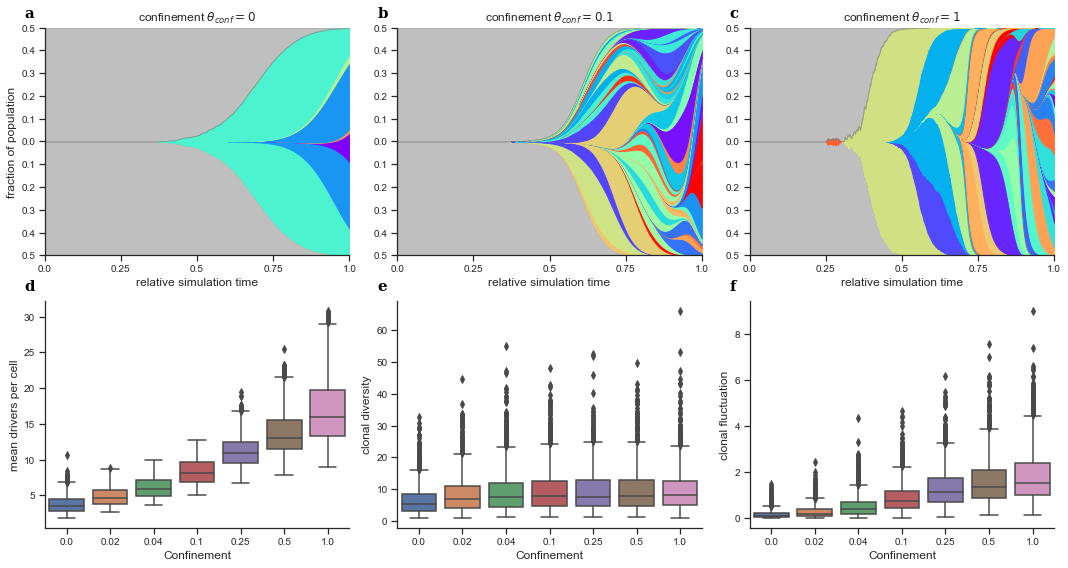

In [9]:
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(15, 8))

# 1st row
for i, ax in enumerate(axs[0, :]):
    plot_final_fish(confinement_data_fish[i], ax)
    if i == 0:
        ax.set_ylabel('fraction of population')
    # else:
    #     ax.set_yticks([])
    theta_conf = '\\theta_{conf}'
    ax.set_title(f'confinement ${theta_conf} = {[0, 0.1, 1][i]}$')


# # 2nd row
plot_confinement_metrics(confinement_data_df, axs[1, :])

# # Final Figure styling
plt.tight_layout()
label_axes(axs)

plt.savefig('figures/main_figure_1.png', bbox_inches='tight')
plt.savefig('figures/main_figure_1.pdf', bbox_inches='tight')

## Fig 4

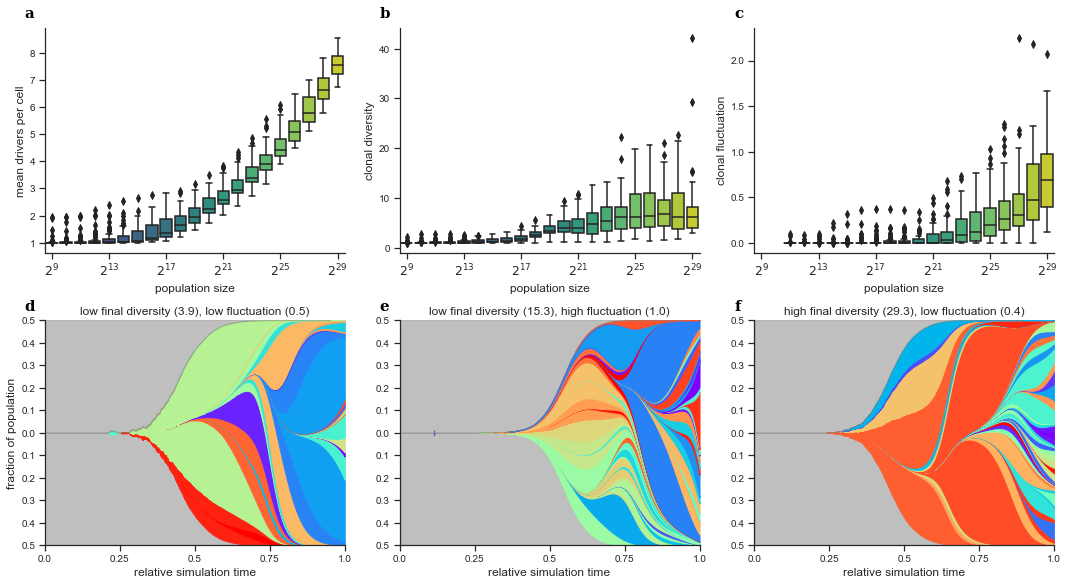

In [10]:
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(15, 8))

# # 3rd row
for i, ax in enumerate(axs[0, :]):
     plot_final_metrics_over_time(metrics_over_time, i, ax)

# # 4th row
target_generation = 20
for i, (ax, r) in enumerate(zip(axs[1, :], [11, 33, 14])):
    plot_final_fish(example_trajectories_fish[r], ax)
    if i == 0:
        ax.set_ylabel('fraction of population')
    
    cur_metrics = example_trajectories_df.loc[(example_trajectories_df['RepeatId']==r)&(example_trajectories_df['GenerationId']==target_generation), ['ClonalDiversity', 'clonal_fluctuation']]
    if i == 0:
        ax.set_title(f'low final diversity ({cur_metrics["ClonalDiversity"].iloc[0]:.1f}), low fluctuation ({cur_metrics["clonal_fluctuation"].iloc[0]:.1f})')
    elif i == 1:
        ax.set_title(f'low final diversity ({cur_metrics["ClonalDiversity"].iloc[0]:.1f}), high fluctuation ({cur_metrics["clonal_fluctuation"].iloc[0]:.1f})')
    elif i == 2:
        ax.set_title(f'high final diversity ({cur_metrics["ClonalDiversity"].iloc[0]:.1f}), low fluctuation ({cur_metrics["clonal_fluctuation"].iloc[0]:.1f})')
    # ax.set_title(f'clonal diversity: {cur_metrics["ClonalDiversity"].iloc[0]:.2f}, clonal fluctuation: {cur_metrics["clonal_fluctuation"].iloc[0]:.2f}')

# # Final Figure styling
plt.tight_layout()
label_axes(axs)

plt.savefig('figures/main_figure_2.png', bbox_inches='tight')
plt.savefig('figures/main_figure_2.pdf', bbox_inches='tight')

## Fig 5

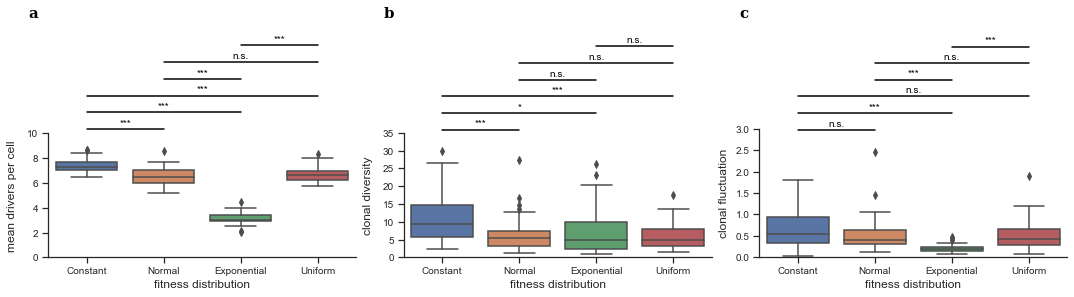

In [11]:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(15, 4))

# # 5th row
for i, ax in enumerate(axs):
    plot_final_fitness(i, fitness_data, ax, h_scale=0.075, hl_scale=0.0, yshift=2)
    if i == 0:
        ax.set_yticks(np.arange(0, 11, 2))

# # Final Figure styling
plt.tight_layout()
label_axes(axs)

plt.savefig('figures/main_figure_3.png', bbox_inches='tight')
plt.savefig('figures/main_figure_3.pdf', bbox_inches='tight')

# Supplementary Figures

## Supp. Fig. 2

In [12]:
files = {}
combined_df = pd.DataFrame()
for f in os.listdir('data/homeostasis'):
    cur = pd.read_csv(os.path.join('data/homeostasis', f))
    files[float(f'0.{f.split(".")[0][1:]}')] = cur
    cur['rate'] = float(f'0.{f.split(".")[0][1:]}')
    combined_df = pd.concat([combined_df, cur])

combined_df = combined_df.reset_index(drop=True).sort_values(['rate', 'RepeatId'])

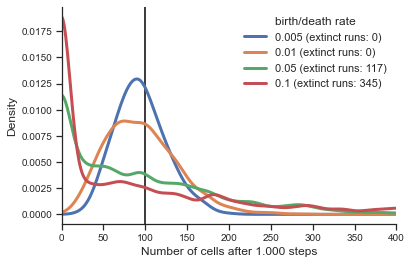

In [13]:
bins = np.histogram(combined_df['aliveCount'], bins=np.linspace(0, 400, 50))[1]

plt.axvline(100, color='black')
for rate in combined_df['rate'].unique():
    count = np.histogram(combined_df.loc[combined_df['rate']==rate, 'aliveCount'], bins=bins, density=True)[0]
    count = np.interp(np.linspace(0, 400, 400), bins[:-1], count)
    count = gaussian_filter(count, 10, mode='reflect' if (combined_df.loc[combined_df['rate']==rate, 'aliveCount']==0).sum()!=0 else 'constant', )

    plt.plot(np.arange(0, 400, 1), count, '-', lw=3,
            label=f"{rate} (extinct runs: {(combined_df.loc[combined_df['rate']==float(rate), 'aliveCount']==0).sum()})")

plt.gca().set_xlabel('Number of cells after 1.000 steps')
plt.gca().set_ylabel('Density')
# plt.gca().set_title('Homeostasis ($p_{birth} = p_{death}$):\nDistribution over 1.000 runs\neach starting at 100 cells')
# plt.gca().set_title('Homeostasis ($p_{birth} = p_{death}$):\nDistribution over 1.000 runs\neach starting at 100 cells')

plt.legend(title='birth/death rate')
plt.xlim(0, 400)
plt.savefig('figures/supp_fig_2.pdf', bbox_inches='tight')
plt.savefig('figures/supp_fig_2.png', bbox_inches='tight', dpi=300)
plt.show()

## Supp. Fig. 3

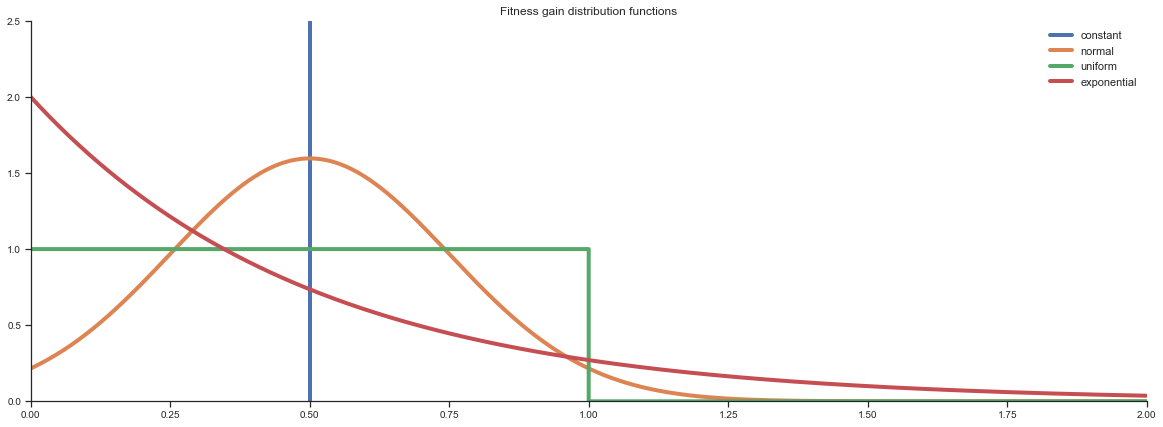

In [14]:
fitness_mean = 0.5
x = np.arange(0, 4*fitness_mean, 0.001)

uniform_dist = 1/ (2*fitness_mean) * np.ones_like(x)
uniform_dist[x > 2*fitness_mean] = 0
exponential_dist = expon.pdf(x, 0, fitness_mean)
beta_dist = beta.pdf(x, 1, 1/fitness_mean - 1)
normal_dist = norm.pdf(x, fitness_mean, 1/2 * fitness_mean)
constant_dist = np.zeros_like(x)
constant_dist[x==fitness_mean] = 20

lw = 4
plt.figure(figsize=(20, 7))
plt.axvline(fitness_mean, lw=lw, label='constant')
plt.plot(x, normal_dist, lw=lw, label='normal', color='C1')
plt.step(x, uniform_dist, lw=lw, label='uniform', color='C2')
plt.plot(x, exponential_dist, lw=lw, label='exponential', color='C3')
plt.legend(facecolor='w')
plt.ylim(0, 2.5)
plt.xlim(0, 4*fitness_mean)
plt.title('Fitness gain distribution functions')
plt.savefig('figures/supp_fig_3.pdf', bbox_inches='tight')
plt.savefig('figures/supp_fig_3.png', bbox_inches='tight', dpi=300)
plt.show()

## Supp. Fig. 4

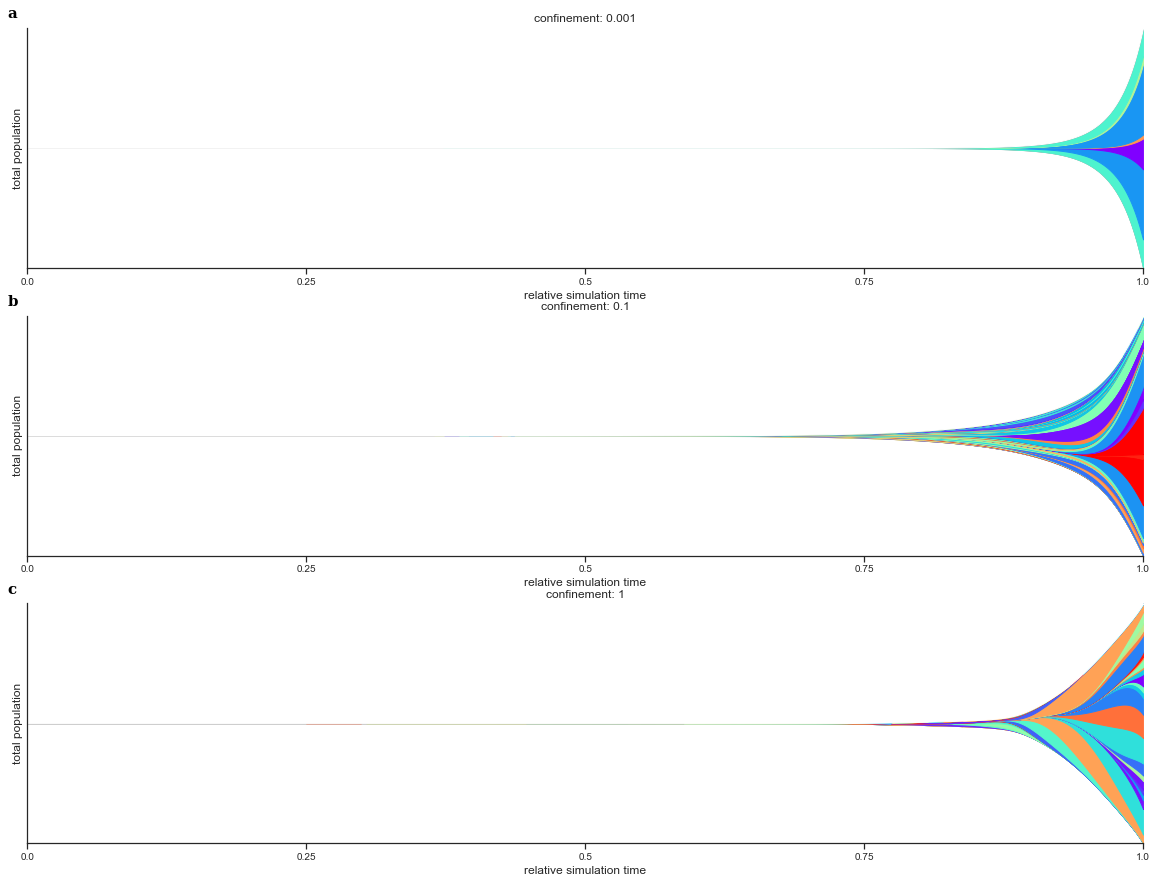

In [15]:
fig, axs = plt.subplots(ncols=1, nrows=3, figsize=(20, 15))

confinement_data_df, confinement_data_fish, cur_lines = load_final_confinement(selection_fish=[41, 19, 35], absolute=True)

# 1st row
for i, ax in enumerate(axs):
    plot_final_fish(confinement_data_fish[i], ax)
    ax.set_ylabel('total population')
    ax.set_yticks([])
    ax.set_title(f'confinement: {[0.001, 0.1, 1][i]}')

label_axes(axs)
plt.savefig('figures/supp_fig_4.png', bbox_inches='tight')
plt.savefig('figures/supp_fig_4.pdf', bbox_inches='tight')

## Supp. Fig. 5

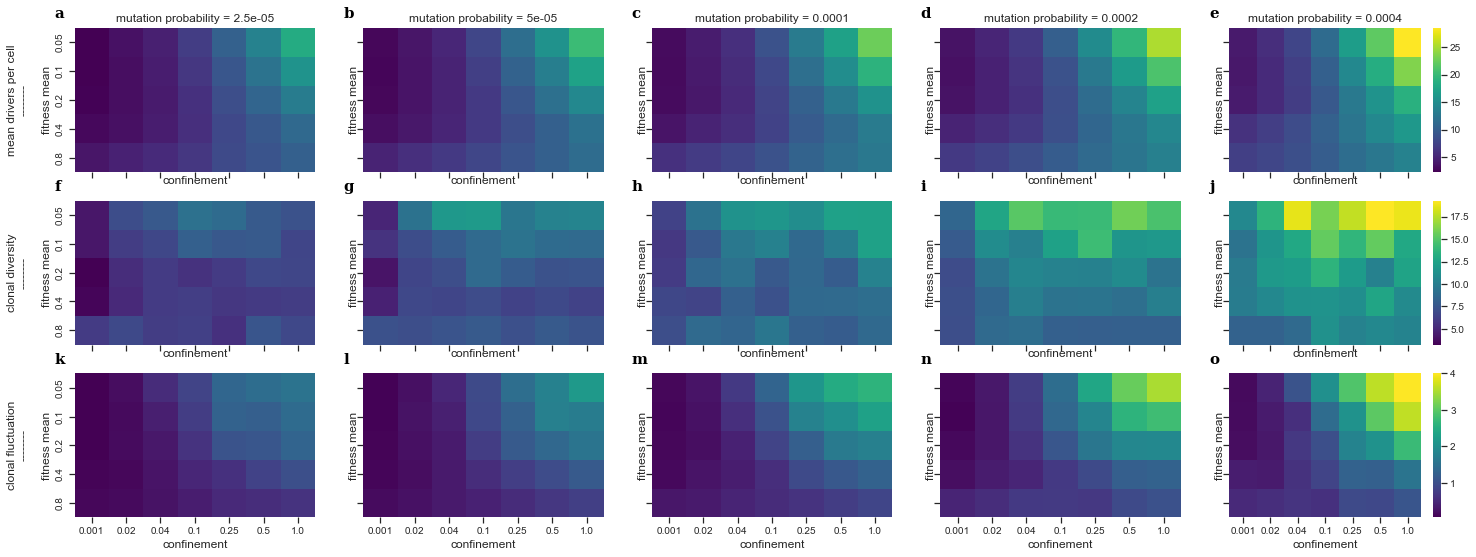

In [16]:
range_MutationProb = [0.000025, 0.00005, 0.0001, 0.0002, 0.0004]
range_FitnessMean = [0.05, 0.1, 0.2, 0.4, 0.8]
range_Confinement = [0.001, 0.02, 0.04, 0.1, 0.25, 0.5, 1]
target_generation = 20

cols = ['MeanDriversPerCell', 'ClonalDiversity', 'clonal_fluctuation']
cols_formatted = ["mean drivers per cell", "clonal diversity", 'clonal fluctuation']

fig, axs = plt.subplots(nrows=len(cols), ncols=5, figsize=(25, 3*len(cols)), sharex=True, sharey=True)

min_vals = {c: 9999 for c in cols}
max_vals = {c: 0 for c in cols}

for ax, cur_MutationProb in zip(axs.T, range_MutationProb):
    vals = {c: pd.DataFrame(index=range_FitnessMean, columns=range_Confinement) for c in cols}

    for cur_FitnessMean in range_FitnessMean:
        for cur_Confinement in range_Confinement:
            cur = pd.read_csv(f'data/parameter_ranges/parameter_range_{cur_MutationProb:.6f}_{cur_FitnessMean:.6f}_{cur_Confinement:.6f}.csv')
            cur['clonal_fluctuation'] = 0
            for r in cur['RepeatId'].unique():
                cur.loc[cur['RepeatId']==r, 'clonal_fluctuation'] = clonal_fluctuation(cur, r)
            cur = cur.loc[cur['GenerationId'] == target_generation]
            cur['fraction_alive_cells'] = cur['CellAliveCount'] / (cur['CellTotalCount'])
            cur['fraction_necro'] = cur['CellNecroCount'] / (cur['CellTotalCount'])
            for c in cols:
                vals[c].loc[cur_FitnessMean, cur_Confinement] = cur[c].mean()

    for c in cols:
        min_vals[c] = min(min_vals[c], vals[c].min().min())
        max_vals[c] = max(max_vals[c], vals[c].max().max())

for ax, cur_MutationProb in zip(axs.T, range_MutationProb):
    vals = {c: pd.DataFrame(index=range_FitnessMean, columns=range_Confinement) for c in cols}

    for cur_FitnessMean in range_FitnessMean:
        for cur_Confinement in range_Confinement:
            cur = pd.read_csv(f'data/parameter_ranges/parameter_range_{cur_MutationProb:.6f}_{cur_FitnessMean:.6f}_{cur_Confinement:.6f}.csv')
            cur['clonal_fluctuation'] = 0
            for r in cur['RepeatId'].unique():
                cur.loc[cur['RepeatId']==r, 'clonal_fluctuation'] = clonal_fluctuation(cur, r)
            cur = cur.loc[cur['GenerationId'] == target_generation]
            cur['fraction_alive_cells'] = cur['CellAliveCount'] / (cur['CellTotalCount'])
            cur['fraction_necro'] = cur['CellNecroCount'] / (cur['CellTotalCount'])
            for c in cols:
                vals[c].loc[cur_FitnessMean, cur_Confinement] = cur[c].mean()

    for i, (a, c) in enumerate(zip(ax, cols)):
        sns.heatmap(vals[c].astype(float), cmap='viridis', ax=a, vmin=min_vals[c], vmax=max_vals[c], cbar=(cur_MutationProb==range_MutationProb[-1]))
        a.set_xlabel('confinement')
        a.set_ylabel('fitness mean')
        
    ax[0].set_title(f'mutation probability = {cur_MutationProb}')

for i, c in enumerate(cols_formatted):
    axs[i, 0].set_ylabel(f'{c}\n--------\n\nfitness mean')

label_axes(axs)
plt.savefig('figures/supp_fig_5.png', bbox_inches='tight')
plt.savefig('figures/supp_fig_5.pdf', bbox_inches='tight')

## Supp. Fig. 6

In [17]:
range_MutationProb = [0.000025, 0.00005, 0.0001, 0.0002, 0.0004]
range_FitnessMean = [0.05, 0.1, 0.2, 0.4, 0.8]
range_Confinement = [0.001, 0.02, 0.04, 0.1, 0.25, 0.5, 1]
target_generation = 20

cols = ['MeanDriversPerCell', 'ClonalDiversity', 'clonal_fluctuation']
cols_formatted = ["mean drivers per cell", "clonal diversity", 'clonal fluctuation']

long_results = pd.DataFrame(columns=['MeanDriversPerCell', 'ClonalDiversity', 'clonal_fluctuation',
                                        'fraction_alive_cells', 'fraction_necro', 'RepeatId', 'MutationProb', 'FitnessMean', 'Confinement'])


for cur_MutationProb in range_MutationProb:
    for cur_FitnessMean in range_FitnessMean:
        for cur_Confinement in range_Confinement:
            cur = pd.read_csv(f'data/parameter_ranges/parameter_range_{cur_MutationProb:.6f}_{cur_FitnessMean:.6f}_{cur_Confinement:.6f}.csv')
            cur['clonal_fluctuation'] = 0
            for r in cur['RepeatId'].unique():
                cur.loc[cur['RepeatId']==r, 'clonal_fluctuation'] = clonal_fluctuation(cur, r)
            cur = cur.loc[cur['GenerationId'] == target_generation]
            cur['fraction_alive_cells'] = cur['CellAliveCount'] / (cur['CellTotalCount'])
            cur['fraction_necro'] = cur['CellNecroCount'] / (cur['CellTotalCount'])
            
            cur['MutationProb'] = cur_MutationProb
            cur['FitnessMean'] = cur_FitnessMean
            cur['Confinement'] = cur_Confinement

            long_results = pd.concat([long_results, cur[['MeanDriversPerCell', 'ClonalDiversity', 'clonal_fluctuation',
                                    'fraction_alive_cells', 'fraction_necro', 'RepeatId', 'MutationProb', 'FitnessMean', 'Confinement']].reset_index(drop=True)]).reset_index(drop=True)
                

long_results = long_results.rename({'MutationProb': 'mutation probability', 'FitnessMean': 'fitness mean', 'Confinement': 'confinement'}, axis=1)

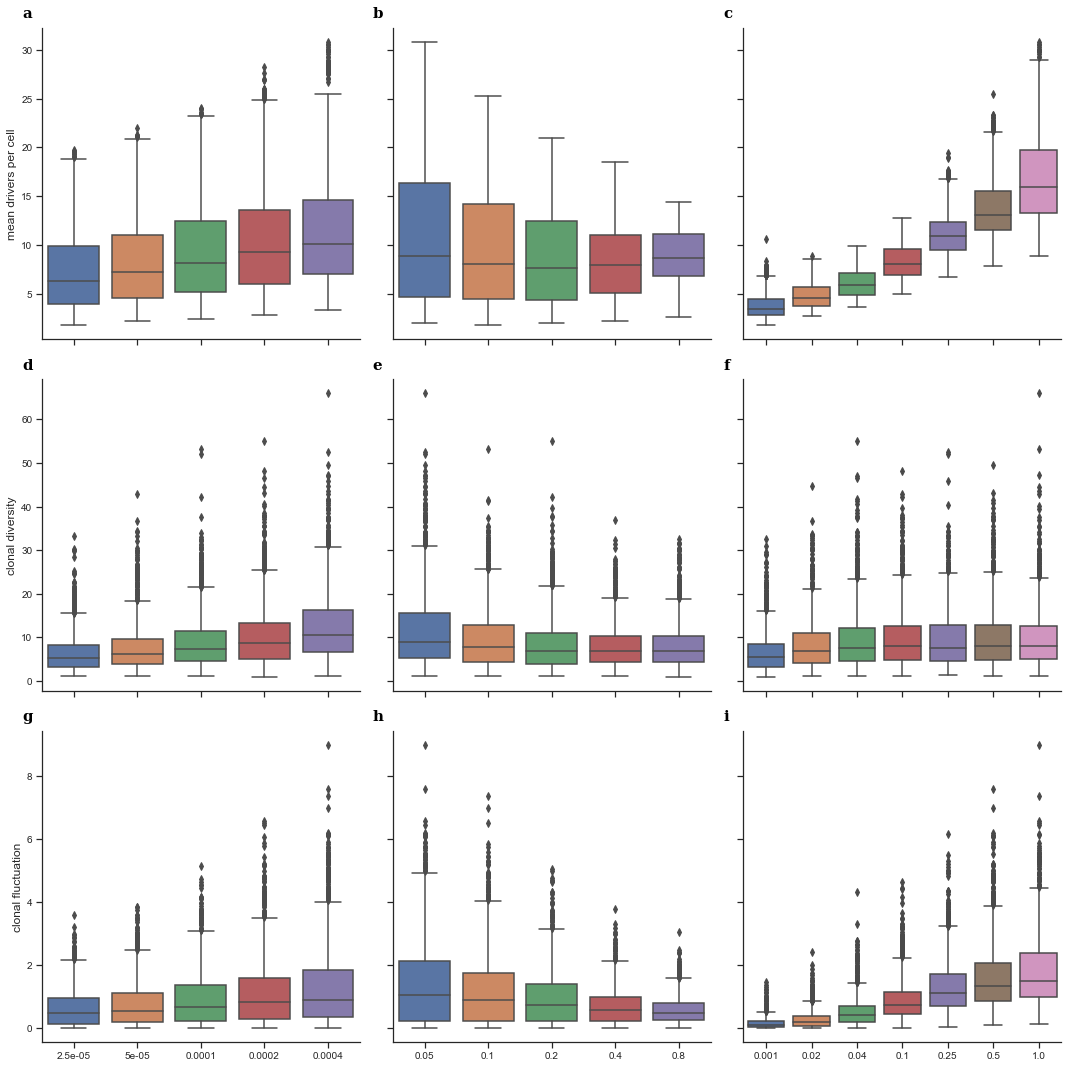

In [18]:
fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(15, 15), sharex='col', sharey='row')
axs = axs.T
for i, (ax, parameter) in enumerate(zip(axs, ['mutation probability', 'fitness mean', 'confinement'])):
    for j, (a, c, cf) in enumerate(zip(ax, cols, cols_formatted)):
        sns.boxplot(data=long_results, y=c, x=parameter, ax=a)
        if i == 0:
            a.set_ylabel(cf)
        else:
            a.set_ylabel('')
        if j != 3:
            a.set_xlabel('')
        # plot_statistical_significance(a, long_results, c, parameter)

label_axes(axs.T)
plt.tight_layout();
plt.savefig('figures/supp_fig_6.png', bbox_inches='tight')
plt.savefig('figures/supp_fig_6.pdf', bbox_inches='tight')

## Supp. Fig. 7

In [19]:
cur = metrics_over_time.loc[:]
# cur = metrics_over_time.loc[(metrics_over_time['GenerationId']>8)]

metrics_over_time = load_final_metrics_over_time()
cols = ['MeanDriversPerCell', 'ClonalDiversity', 'clonal_fluctuation']
cols_formatted = ["mean drivers per cell", "clonal diversity", 'clonal fluctuation']
hue_order = np.append('$2^{9}$', np.sort(cur['Generation_label'].unique())[:-1])

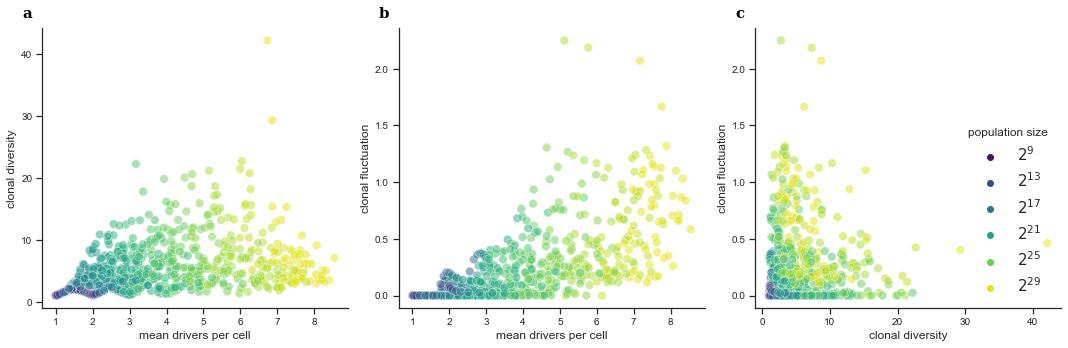

In [20]:
legend_ax = 2

fig, axs = plt.subplots(ncols=len(list(itertools.combinations(cols, 2))),  figsize=(15, 5))


for i, (ax, (m1, m2), (mf1, mf2)) in enumerate(zip(axs, itertools.combinations(cols, 2), itertools.combinations(cols_formatted, 2))):
    sns.scatterplot(data=cur, x=m1, y=m2,
                    ax=ax, hue='Generation_label', palette='viridis', alpha=0.5, s=75,
                    hue_order=hue_order, legend=(i==legend_ax))
    ax.set_xlabel(mf1)
    ax.set_ylabel(mf2)

handles, labels = axs[legend_ax].get_legend_handles_labels()
axs[legend_ax].legend(handles[::4], labels[::4], title='population size', loc='lower right', fontsize=15)

label_axes(axs)
plt.tight_layout()
plt.savefig('figures/supp_fig_7.png', bbox_inches='tight')
plt.savefig('figures/supp_fig_7.pdf', bbox_inches='tight')

## Supp. Fig. 8

In [5]:
metrics_over_time = load_final_metrics_over_time()
cols = ['MeanDriversPerCell', 'ClonalDiversity']
cols_formatted = ["mean drivers per cell", "clonal diversity", 'clonal fluctuation']
hue_order = np.append('$2^{9}$', np.sort(metrics_over_time['Generation_label'].unique())[:-1])

selection = [11, 14, 21, 22, 30, 31, 47]

metrics_over_time['selection'] = False
metrics_over_time.loc[metrics_over_time['RepeatId'].isin(selection), 'selection'] = True

example_trajectories_df, example_trajectories_fish, _ = load_final_example_trajectories(first_gen=8, selection=selection)

NameError: name 'cur_FitnessDist' is not defined

In [7]:
example_trajectories_df, example_trajectories_fish, _ = load_final_example_trajectories(
    first_gen=8, selection=[11, 14, 21, 22, 30, 31, 47])


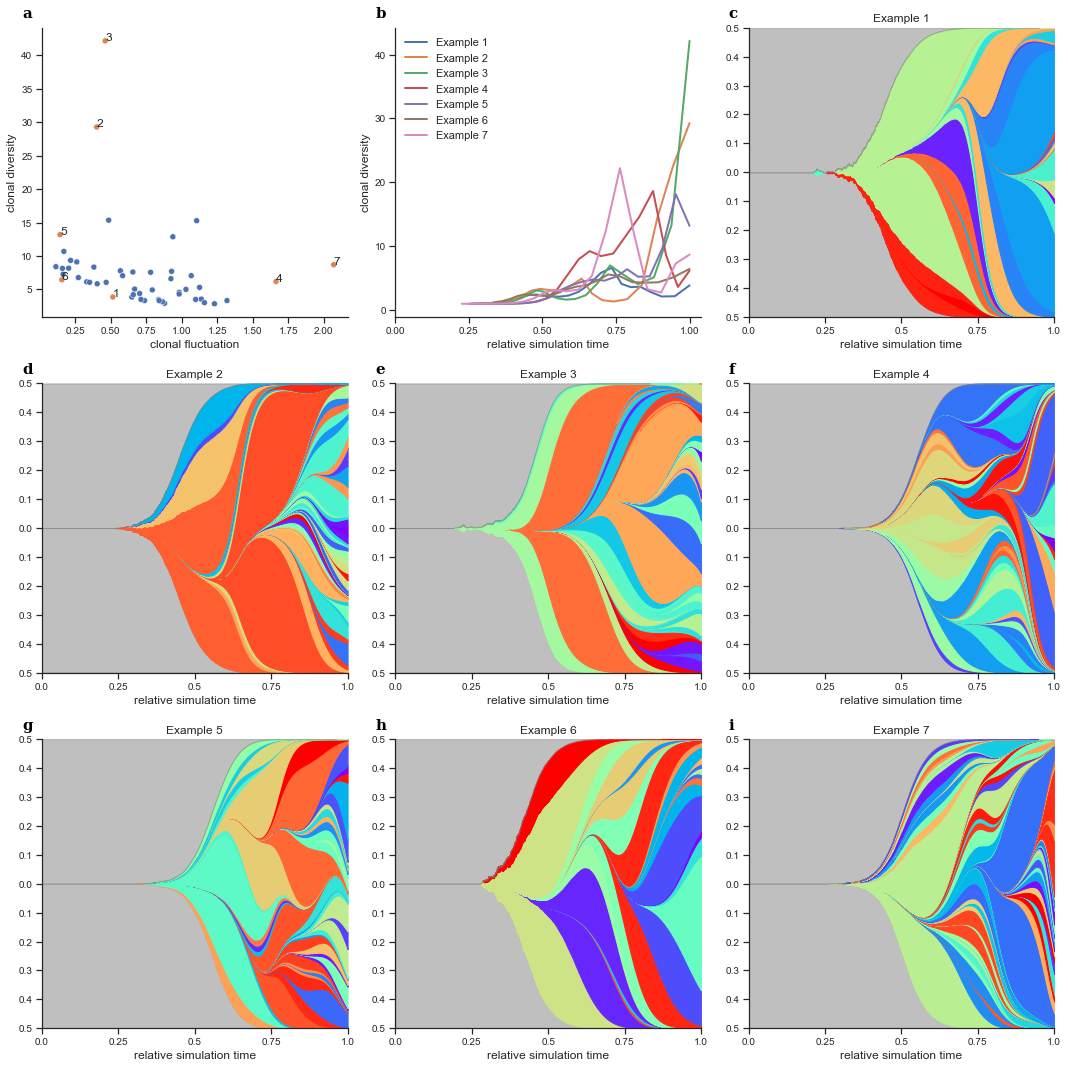

In [22]:
fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(15, 15))

# Panel a
cur = metrics_over_time.loc[(metrics_over_time['GenerationId']==20)]
sns.scatterplot(data=cur, x='clonal fluctuation', y='clonal diversity', hue='selection', ax=axs[0, 0], legend=False)
for i, r in enumerate(selection):
    axs[0, 0].text(cur.loc[cur['RepeatId']==r, 'clonal fluctuation'], cur.loc[cur['RepeatId']==r, 'clonal diversity'], i+1)
# for r in range(50):
#     axs[0, 0].text(cur.loc[cur['RepeatId']==r, 'clonal fluctuation'], cur.loc[cur['RepeatId']==r, 'clonal diversity'], r)

cur = metrics_over_time.loc[metrics_over_time['selection']]

# Panel b
plot_final_example_trajectories(cur, axs[0, 1], selection_names=[f'Example {i+1}' for i, _ in enumerate(selection)])

# Rest
for i, (ax, r) in enumerate(zip(axs.flat[2:], selection)):
    plot_final_fish(example_trajectories_fish[r], ax)
    # if i == 0:
    #     ax.set_ylabel('fraction of population')
    ax.set_title(f'Example {i+1}')

label_axes(axs)
plt.tight_layout()
plt.savefig('figures/supp_fig_8.png', bbox_inches='tight')
plt.savefig('figures/supp_fig_8.pdf', bbox_inches='tight')

## Supp. Fig. 9

In [23]:
cur_FitnessMean = 0.2
range_FitnessDist = [0, 1, 2, 3]
range_FitnessAcc = [0, 1, 2]
range_FitnessEffect = [0, 1, 2]

key_FitnessDist = {0: "constant", 1: "normal", 2: "exponential", 3: "uniform"}
key_FitnessAcc = {0: "multiplicative", 1: "additive", 2: "limited multiplicative"}
key_FitnessEffect = {0: "birth", 1: "death", 2: "both"}

target_generation = 20

cur_FitnessMean = 0.2

cols = ['MeanDriversPerCell', 'ClonalDiversity']

cur_FitnessDist = 0
cur_FitnessEffect = 0
cur_FitnessAcc = 0
long_results = pd.DataFrame(columns=['MeanDriversPerCell', 'ClonalDiversity', 'clonal_fluctuation', 'FitnessDist',
                                        'FitnessAcc', 'FitnessEffect', 'RepeatId', 'Generations'])
for cur_FitnessDist in range_FitnessDist:
    cur = pd.read_csv(f'data/fitness/fitness_{cur_FitnessMean:.3f}_{cur_FitnessDist}_{cur_FitnessAcc}_{cur_FitnessEffect}.csv')
    cur['clonal_fluctuation'] = 0
    for r in cur['RepeatId'].unique():
        for gen in range(target_generation+1):
            cur.loc[(cur['RepeatId']==r) & (cur['GenerationId']==gen), 'clonal_fluctuation'] = clonal_fluctuation(cur.loc[cur['GenerationId']<gen], r)
    cur = cur.loc[cur['GenerationId'] == target_generation]

    cur['FitnessDist'] = cur_FitnessDist
    cur['FitnessEffect'] = cur_FitnessEffect
    cur['FitnessAcc'] = cur_FitnessAcc

    long_results = pd.concat([long_results, cur[['MeanDriversPerCell', 'ClonalDiversity', 'clonal_fluctuation', 'FitnessDist',
                            'FitnessAcc', 'FitnessEffect', 'RepeatId', 'Generations']].reset_index(drop=True)]).reset_index(drop=True)


cur_FitnessDist = 0
cur_FitnessEffect = 0
cur_FitnessAcc = 0
for cur_FitnessAcc in range_FitnessAcc:
    cur = pd.read_csv(f'data/fitness/fitness_{cur_FitnessMean:.3f}_{cur_FitnessDist}_{cur_FitnessAcc}_{cur_FitnessEffect}.csv')
    cur['clonal_fluctuation'] = 0
    for r in cur['RepeatId'].unique():
        for gen in range(target_generation+1):
            cur.loc[(cur['RepeatId']==r) & (cur['GenerationId']==gen), 'clonal_fluctuation'] = clonal_fluctuation(cur.loc[cur['GenerationId']<gen], r)
    cur = cur.loc[cur['GenerationId'] == target_generation]

    cur['FitnessDist'] = cur_FitnessDist
    cur['FitnessEffect'] = cur_FitnessEffect
    cur['FitnessAcc'] = cur_FitnessAcc

    long_results = pd.concat([long_results, cur[['MeanDriversPerCell', 'ClonalDiversity', 'clonal_fluctuation', 'FitnessDist',
                            'FitnessAcc', 'FitnessEffect', 'RepeatId', 'Generations']].reset_index(drop=True)]).reset_index(drop=True)

cur_FitnessDist = 0
cur_FitnessEffect = 0
cur_FitnessAcc = 0
for cur_FitnessEffect in range_FitnessEffect:
    cur = pd.read_csv(f'data/fitness/fitness_{cur_FitnessMean:.3f}_{cur_FitnessDist}_{cur_FitnessAcc}_{cur_FitnessEffect}.csv')
    cur['clonal_fluctuation'] = 0
    for r in cur['RepeatId'].unique():
        for gen in range(target_generation+1):
            cur.loc[(cur['RepeatId']==r) & (cur['GenerationId']==gen), 'clonal_fluctuation'] = clonal_fluctuation(cur.loc[cur['GenerationId']<gen], r)
    cur = cur.loc[cur['GenerationId'] == target_generation]

    cur['FitnessDist'] = cur_FitnessDist
    cur['FitnessEffect'] = cur_FitnessEffect
    cur['FitnessAcc'] = cur_FitnessAcc

    long_results = pd.concat([long_results, cur[['MeanDriversPerCell', 'ClonalDiversity', 'clonal_fluctuation', 'FitnessDist',
                            'FitnessAcc', 'FitnessEffect', 'RepeatId', 'Generations']].reset_index(drop=True)]).reset_index(drop=True)

# long_results['FitnessDist'] = long_results['FitnessDist'].apply(lambda x: key_FitnessDist[x])
# long_results['FitnessAcc'] = long_results['FitnessAcc'].apply(lambda x: key_FitnessAcc[x])
# long_results['FitnessEffect'] = long_results['FitnessEffect'].apply(lambda x: key_FitnessEffect[x])

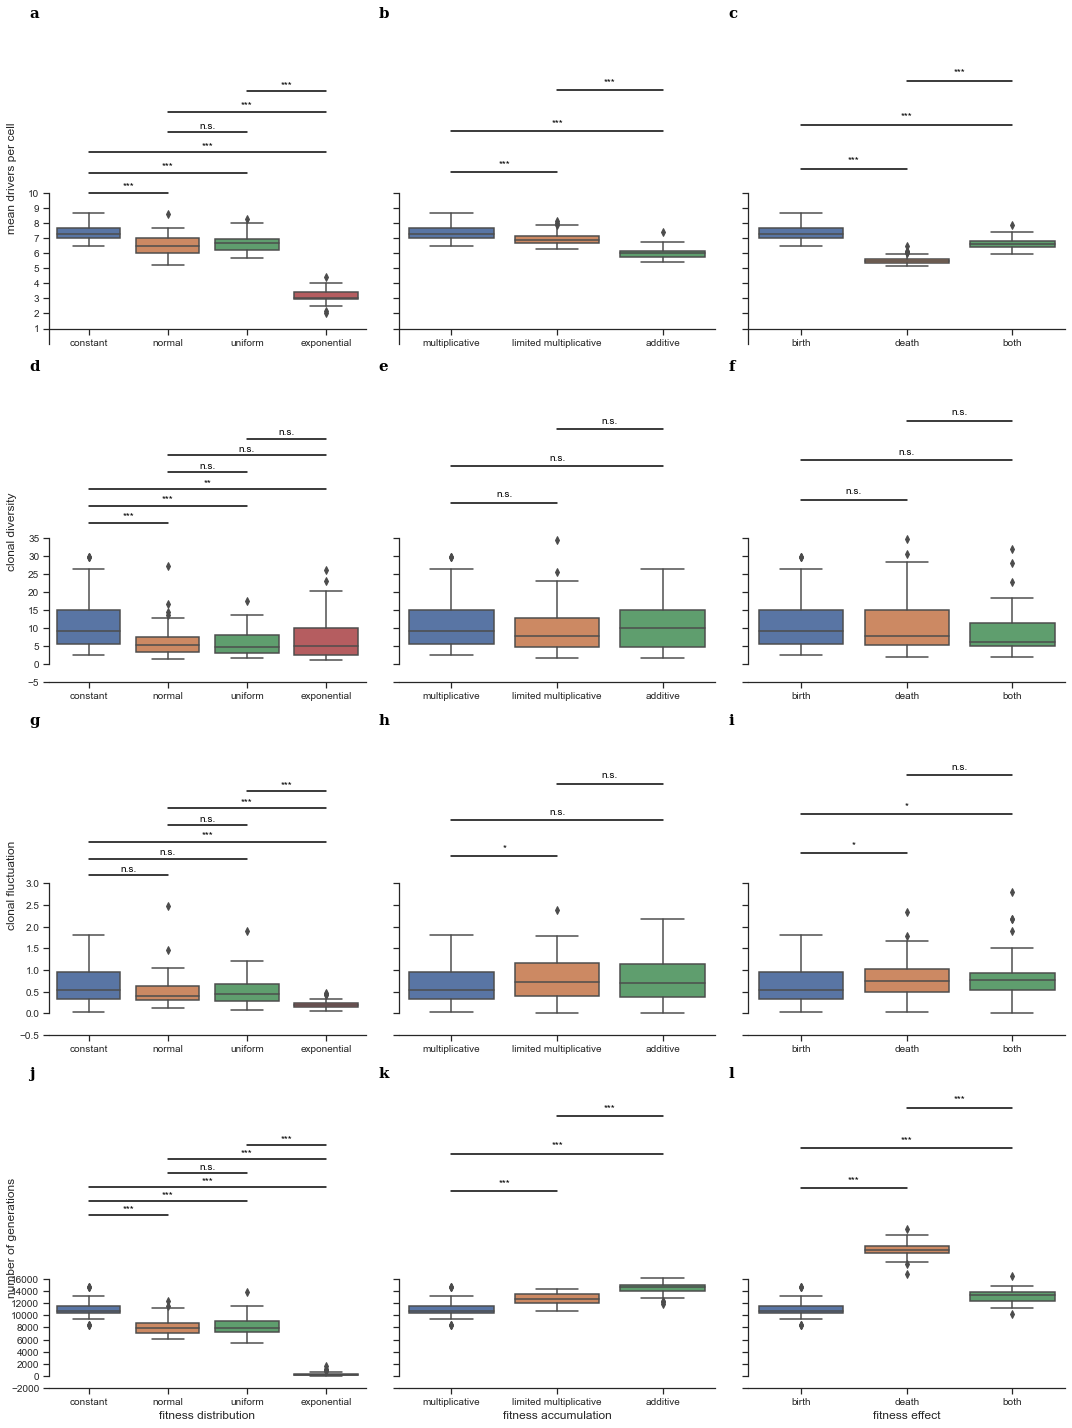

In [24]:
cols = ['MeanDriversPerCell', 'ClonalDiversity', 'clonal_fluctuation', 'Generations']
cols_formatted = ["mean drivers per cell", "clonal diversity", 'clonal fluctuation', 'number of generations']
x_orders = {'FitnessDist': [key_FitnessDist[x] for x in [0, 1, 3, 2]], 'FitnessAcc': [key_FitnessAcc[x] for x in [0, 2, 1]], 'FitnessEffect': [key_FitnessEffect[x] for x in [0, 1, 2]]}
h_scale = 0.075
hl_scale = 0.0
yshift = 2
ystart = dict()

fig, axs = plt.subplots(ncols=3, nrows=4, figsize=(15, 20), sharey='row'
                       )
axs = axs.T
for i, (ax, parameter, pf) in enumerate(zip(axs, ['FitnessDist', 'FitnessAcc', 'FitnessEffect'], ['fitness distribution', 'fitness accumulation', 'fitness effect'])):
    cur = long_results.loc[:]
    for p in np.setdiff1d(['FitnessDist', 'FitnessAcc', 'FitnessEffect'], parameter):
        cur = cur.loc[cur[p] == 0]
    cur['FitnessDist'] = cur['FitnessDist'].apply(lambda x: key_FitnessDist[x])
    cur['FitnessAcc'] = cur['FitnessAcc'].apply(lambda x: key_FitnessAcc[x])
    cur['FitnessEffect'] = cur['FitnessEffect'].apply(lambda x: key_FitnessEffect[x])
    
    for j, (a, c, cf) in enumerate(zip(ax, cols, cols_formatted)):
        
        sns.boxplot(data=cur, y=c, x=parameter, ax=a, order=x_orders[parameter])
        if i==0:
            ystart[c] = long_results[c].max()
        yticks = a.get_yticks()
        spine_height = a.get_ylim()[1]
        plot_statistical_significance(a, cur, c, parameter, h_scale=h_scale, hl_scale=hl_scale, yshift=yshift, ystart=ystart[c])
        a.set_yticks(yticks)
        a.spines['left'].set_bounds((0, yticks[-1]))
        a.yaxis.set_label_coords(-0.1, 0.5 * yticks[-1] / a.get_ylim()[1])
        a.set_ylabel(cols_formatted[i], ha='center')
        a.set_xlabel('fitness distribution')

        if i == 0:
            a.set_ylabel(cf)
        else:
            a.set_ylabel('')
        if j == 3:
            a.set_xlabel(pf)
        else:
            a.set_xlabel('')

label_axes(axs.T)
plt.tight_layout();
plt.savefig('figures/supp_fig_9.png', bbox_inches='tight')
plt.savefig('figures/supp_fig_9.pdf', bbox_inches='tight')